# 3. Price scenarios

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import datetime
import polars.selectors as cs

In [2]:
df = pl.read_csv("data/data_2.csv", try_parse_dates=True)
scenario_cols = df.select(cs.starts_with("Scenarij_")).columns
df

Datum,Scenarij_1,Scenarij_2,Scenarij_3,Scenarij_4,Scenarij_5,Scenarij_6,Scenarij_7,Scenarij_8,Scenarij_9,Scenarij_10,Scenarij_11,Scenarij_12,Scenarij_13,Scenarij_14,Scenarij_15,Scenarij_16,Scenarij_17,Scenarij_18,Scenarij_19,Scenarij_20,Scenarij_21,Scenarij_22,Scenarij_23,Scenarij_24,Scenarij_25,Scenarij_26,Scenarij_27,Scenarij_28,Scenarij_29,Scenarij_30,Scenarij_31,Scenarij_32,Scenarij_33,Scenarij_34,Scenarij_35,Scenarij_36,…,Scenarij_64,Scenarij_65,Scenarij_66,Scenarij_67,Scenarij_68,Scenarij_69,Scenarij_70,Scenarij_71,Scenarij_72,Scenarij_73,Scenarij_74,Scenarij_75,Scenarij_76,Scenarij_77,Scenarij_78,Scenarij_79,Scenarij_80,Scenarij_81,Scenarij_82,Scenarij_83,Scenarij_84,Scenarij_85,Scenarij_86,Scenarij_87,Scenarij_88,Scenarij_89,Scenarij_90,Scenarij_91,Scenarij_92,Scenarij_93,Scenarij_94,Scenarij_95,Scenarij_96,Scenarij_97,Scenarij_98,Scenarij_99,Scenarij_100
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020-01-17,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,…,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0
2020-01-18,50.85,50.16,50.86,50.22,50.32,49.42,50.4,49.22,49.88,49.07,50.82,49.64,49.08,50.08,49.15,50.39,50.04,49.83,50.35,49.02,50.23,49.57,51.22,50.37,50.2,50.05,50.18,50.75,49.42,48.91,50.27,50.05,49.59,50.92,50.73,51.71,…,50.51,50.79,49.42,50.33,49.46,49.8,50.52,50.29,51.41,50.49,49.58,50.45,49.96,50.09,50.09,50.2,50.5,49.3,49.22,49.86,49.82,49.89,50.08,49.5,49.63,49.78,49.2,50.15,49.98,48.82,50.05,49.63,50.01,51.12,50.72,50.11,49.9
2020-01-19,51.94,50.58,50.91,50.14,50.57,48.72,50.03,48.65,50.62,49.28,50.59,49.81,50.5,49.74,48.7,49.55,50.56,49.68,49.46,49.31,49.16,49.79,51.42,50.43,50.02,50.65,50.57,51.85,48.5,48.03,50.08,50.73,49.42,51.45,52.24,51.76,…,50.91,51.62,49.07,51.47,49.57,49.91,49.95,50.6,52.02,51.13,48.89,50.51,50.25,50.8,49.96,49.64,50.78,48.73,48.44,49.11,49.44,50.34,49.89,49.06,50.44,50.29,49.23,50.92,50.5,49.62,50.18,49.3,49.44,51.44,50.49,51.5,49.53
2020-01-20,51.23,51.3,51.06,51.73,50.13,49.65,50.42,48.53,50.3,49.22,50.68,49.73,50.37,49.71,48.62,50.84,51.17,49.41,50.37,49.13,48.25,48.54,51.88,50.16,49.66,51.09,52.29,52.91,49.61,47.85,50.06,50.64,49.66,50.62,52.11,51.36,…,51.81,50.39,49.58,50.41,48.73,49.92,48.83,51.59,52.47,51.07,48.62,50.63,49.77,50.61,50.57,49.72,50.62,48.51,48.91,49.71,48.99,50.34,49.37,49.46,49.74,50.43,48.87,51.11,50.24,50.0,50.64,49.45,49.16,51.72,49.61,51.21,50.37
2020-01-21,52.38,50.6,51.63,50.95,50.5,50.62,51.35,48.42,50.14,48.84,50.47,50.52,49.84,49.72,48.83,50.53,50.86,49.23,52.0,49.01,49.08,48.07,51.72,49.97,49.38,49.7,51.9,53.48,49.27,47.63,49.15,50.27,49.71,51.89,51.61,51.59,…,52.08,50.3,48.37,51.34,50.76,49.84,48.65,51.63,52.13,50.56,47.56,50.78,49.94,50.79,49.53,49.36,50.25,48.56,50.43,50.22,49.27,50.45,48.22,50.24,50.2,49.37,47.81,51.0,49.59,50.65,51.11,49.86,48.72,51.31,49.85,51.17,49.34
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2020-04-26,45.52,46.48,53.95,43.48,40.06,51.52,52.69,48.2,47.07,49.36,37.25,54.07,48.5,35.13,44.1,47.31,45.77,48.14,44.42,52.9,56.47,56.14,40.71,48.45,47.03,47.21,47.19,55.34,43.19,45.54,43.81,41.73,41.84,46.93,43.8,54.85,…,54.4,46.21,34.92,50.4,47.45,47.58,44.41,45.62,48.18,50.26,38.5,50.31,49.93,50.47,52.86,46.34,39.84,46.85,39.72,46.49,41.96,44.69,49.81,53.6,45.18,44.23,41.87,50.48,53.31,50.56,49.56,51.45,52.3,46.24,49.08,44.37,47.27
2020-04-27,45.36,47.18,54.73,44.28,39.83,52.09,52.62,47.83,46.55,49.22,36.71,53.

## a) Expected value on 1.4.2020

The expected value is the mean across all 100 scenarios for that date.

In [3]:
target_date = pl.date(2020, 4, 1)
df = df.with_columns(
    pl.mean_horizontal(scenario_cols).alias("expected_value")
)

In [4]:
vals = df.filter(pl.col("Datum") == target_date).select(scenario_cols).to_numpy().ravel()

In [5]:
import os
os.makedirs("figures", exist_ok=True)

prices = df.select(scenario_cols).to_numpy()          # shape (105, 100)
dates  = df["Datum"].to_list()

prices_apr1   = vals                                   # 1-D, already defined above
expected_value = float(vals.mean())

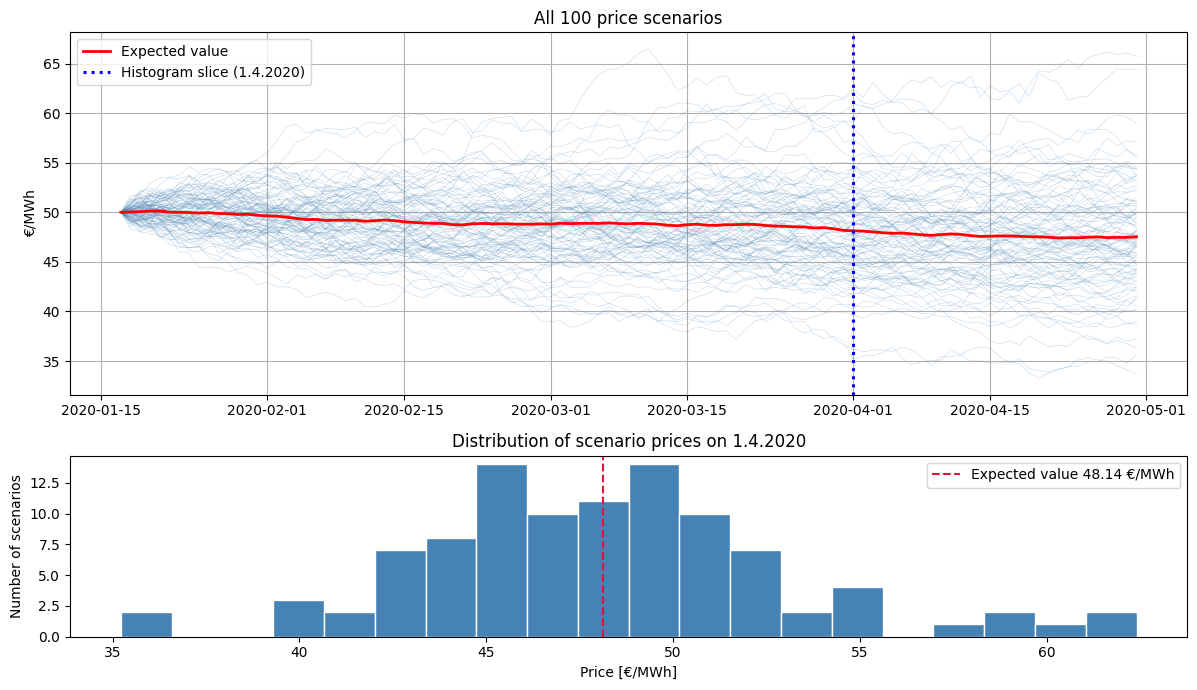

In [6]:

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [2, 1]}
)

# --- Top: all 100 scenario paths ---
for j in range(prices.shape[1]):
    ax_top.plot(dates, prices[:, j], color="steelblue", linewidth=0.4, alpha=0.3)
ax_top.plot(dates, df["expected_value"], color="red", linewidth=2, label="Expected value")
ax_top.axvline(datetime.date(2020, 4, 1), color="blue", linewidth=2.2, linestyle=":",
               label="Histogram slice (1.4.2020)")
ax_top.set_ylabel("€/MWh")
ax_top.set_title("All 100 price scenarios")
ax_top.legend()
ax_top.grid()

# --- Bottom: histogram of prices on 1.4.2020 ---
ax_bot.hist(vals.ravel(), bins=20, color="steelblue", edgecolor="white")
ev = vals.ravel().mean()
ax_bot.axvline(ev, color="crimson", linewidth=1.5, linestyle="--",
               label=f"Expected value {ev:.2f} €/MWh")
ax_bot.set_xlabel("Price [€/MWh]")
ax_bot.set_ylabel("Number of scenarios")
ax_bot.set_title("Distribution of scenario prices on 1.4.2020")
ax_bot.legend()

plt.tight_layout()
plt.savefig("figures/task_3a_scenarios.png", dpi=150)
plt.show()


## b) Algorithm profit in scenario #77

The algorithm has perfect next-day foresight and can hold at most 1 unit. The optimal strategy is greedy: buy whenever tomorrow is higher, sell whenever tomorrow is lower (or equal). On the last day any open position is closed.

In [7]:
def algo_profit(p: np.ndarray):
    """Greedy perfect-foresight trading. Returns (profit, list of (action, day_idx, price))."""
    profit = 0.0
    holding = False
    buy_price = 0.0
    trades = []

    for i in range(len(p) - 1):
        if not holding and p[i + 1] > p[i]:
            holding = True
            buy_price = p[i]
            trades.append(("BUY",  i, p[i]))
        elif holding and p[i + 1] <= p[i]:
            profit += p[i] - buy_price
            trades.append(("SELL", i, p[i]))
            holding = False

    if holding:  # close on last day
        profit += p[-1] - buy_price
        trades.append(("SELL", len(p) - 1, p[-1]))

    return profit, trades

In [8]:
s77_idx = scenario_cols.index("Scenarij_77")
p77 = prices[:, s77_idx]

profit77, trades77 = algo_profit(p77)
print(f"Scenario #77 profit: {profit77:.2f} €/MWh\n")
print(f"{'Action':<6}  {'Date':<12}  {'Price':>10}")
print("-" * 33)
for action, idx, price in trades77:
    print(f"{action:<6}  {str(dates[idx]):<12}  {price:>10.2f}")

Scenario #77 profit: 27.15 €/MWh

Action  Date               Price
---------------------------------
BUY     2020-01-17         50.00
SELL    2020-01-19         50.80
BUY     2020-01-20         50.61
SELL    2020-01-21         50.79
BUY     2020-01-24         49.56
SELL    2020-01-28         52.29
BUY     2020-02-05         48.77
SELL    2020-02-06         49.04
BUY     2020-02-08         48.15
SELL    2020-02-10         48.38
BUY     2020-02-11         48.02
SELL    2020-02-12         48.39
BUY     2020-02-17         47.17
SELL    2020-02-18         47.96
BUY     2020-02-22         45.62
SELL    2020-02-23         46.59
BUY     2020-02-25         45.32
SELL    2020-02-26         45.60
BUY     2020-02-28         44.93
SELL    2020-03-01         45.72
BUY     2020-03-02         45.01
SELL    2020-03-03         45.17
BUY     2020-03-04         44.68
SELL    2020-03-06         45.31
BUY     2020-03-07         45.23
SELL    2020-03-08         45.94
BUY     2020-03-11         44.74
SELL    

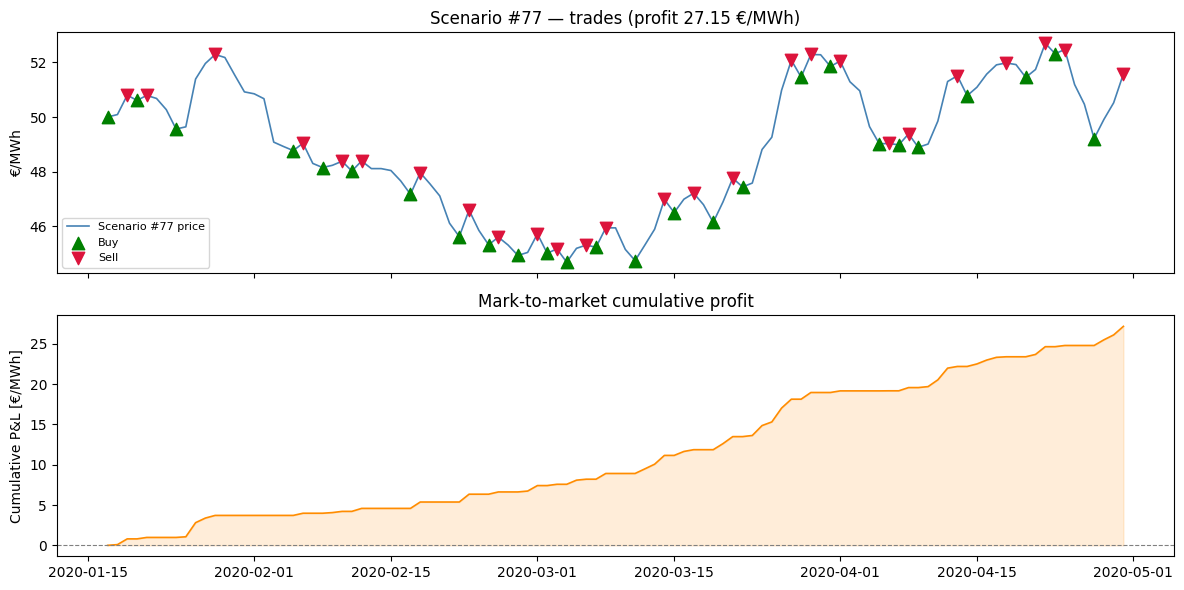

In [9]:
buy_map  = {idx: pr for a, idx, pr in trades77 if a == "BUY"}
sell_map = {idx: pr for a, idx, pr in trades77 if a == "SELL"}

# Mark-to-market cumulative P&L at each day
cum_pnl = np.zeros(len(p77))
realized_local, holding_local, bp_local = 0.0, False, 0.0
for i in range(len(p77)):
    if i in buy_map:
        holding_local, bp_local = True, buy_map[i]
    if i in sell_map:
        realized_local += sell_map[i] - bp_local
        holding_local = False
    cum_pnl[i] = realized_local + ((p77[i] - bp_local) if holding_local else 0.0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Price + trades
ax1.plot(dates, p77, color="steelblue", linewidth=1.2, label="Scenario #77 price")
buys  = [(dates[i], pr) for a, i, pr in trades77 if a == "BUY"]
sells = [(dates[i], pr) for a, i, pr in trades77 if a == "SELL"]
if buys:
    ax1.scatter(*zip(*buys),  marker="^", color="green",  s=80, zorder=5, label="Buy")
if sells:
    ax1.scatter(*zip(*sells), marker="v", color="crimson", s=80, zorder=5, label="Sell")
ax1.set_ylabel("€/MWh")
ax1.set_title(f"Scenario #77 — trades (profit {profit77:.2f} €/MWh)")
ax1.legend(fontsize=8)

# Cumulative P&L
ax2.plot(dates, cum_pnl, color="darkorange", linewidth=1.2)
ax2.fill_between(dates, cum_pnl, alpha=0.15, color="darkorange")
ax2.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Cumulative P&L [€/MWh]")
ax2.set_title("Mark-to-market cumulative profit")

plt.tight_layout()
plt.savefig("figures/task_3b_scenario77.png", dpi=150)
plt.show()


## c) Profit across all scenarios

In [10]:
all_profits = []
for j, col in enumerate(scenario_cols):
    p, _ = algo_profit(prices[:, j])
    all_profits.append(p)

all_profits = np.array(all_profits)
best_idx  = int(np.argmax(all_profits))
best_scen = scenario_cols[best_idx]

print(f"Most profitable scenario: {best_scen}  →  {all_profits[best_idx]:.2f} €/MWh")
print(f"Mean profit across all scenarios: {all_profits.mean():.2f} €/MWh")
print(f"Min profit: {all_profits.min():.2f}   Max: {all_profits.max():.2f}")

Most profitable scenario: Scenarij_48  →  39.87 €/MWh
Mean profit across all scenarios: 24.09 €/MWh
Min profit: 14.06   Max: 39.87


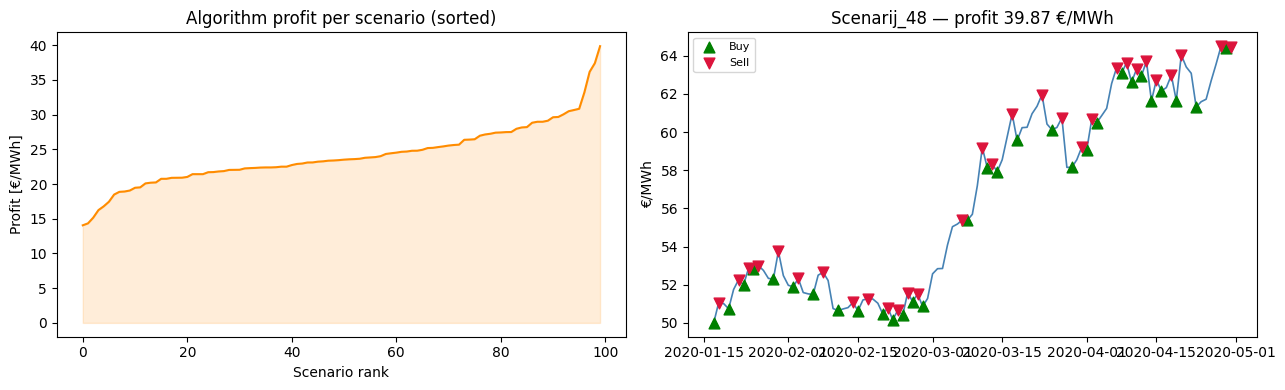

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: sorted profit as a filled line
order = np.argsort(all_profits)
sorted_profits = all_profits[order]
ax = axes[0]
ax.plot(range(len(sorted_profits)), sorted_profits, color="darkorange", linewidth=1.5)
ax.fill_between(range(len(sorted_profits)), sorted_profits, alpha=0.15, color="darkorange")
ax.set_xlabel("Scenario rank")
ax.set_ylabel("Profit [€/MWh]")
ax.set_title("Algorithm profit per scenario (sorted)")

# Right: price path of best scenario
ax2 = axes[1]
p_best = prices[:, best_idx]
_, trades_best = algo_profit(p_best)
ax2.plot(dates, p_best, color="steelblue", linewidth=1.2)
buys_b  = [(dates[i], pr) for a, i, pr in trades_best if a == "BUY"]
sells_b = [(dates[i], pr) for a, i, pr in trades_best if a == "SELL"]
if buys_b:
    ax2.scatter(*zip(*buys_b),  marker="^", color="green",  s=60, zorder=5, label="Buy")
if sells_b:
    ax2.scatter(*zip(*sells_b), marker="v", color="crimson", s=60, zorder=5, label="Sell")
ax2.set_ylabel("€/MWh")
ax2.set_title(f"{best_scen} — profit {all_profits[best_idx]:.2f} €/MWh")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/task_3c_profits.png", dpi=150)
plt.show()


## d) Value of the call option

The option gives the right to **buy on 1.4.2020 at a strike of 55 €/MWh**. Its payoff in each scenario is:

$$\text{payoff} = \max(0,\ P_{\text{1.4.2020}} - 55)$$

The value of the option is the average payoff across all 100 scenarios (Monte Carlo expectation).

In [12]:
strike = 55.0
payoffs = np.maximum(0, prices_apr1 - strike)

option_value = payoffs.mean()
in_the_money = (prices_apr1 > strike).sum()

print(f"Option value (expected payoff): {option_value:.2f} €/MWh")
print(f"In-the-money scenarios: {in_the_money} / {len(prices_apr1)}")
print(f"Payoff range: {payoffs.min():.2f} – {payoffs.max():.2f} €/MWh")

Option value (expected payoff): 0.31 €/MWh
In-the-money scenarios: 7 / 100
Payoff range: 0.00 – 7.41 €/MWh


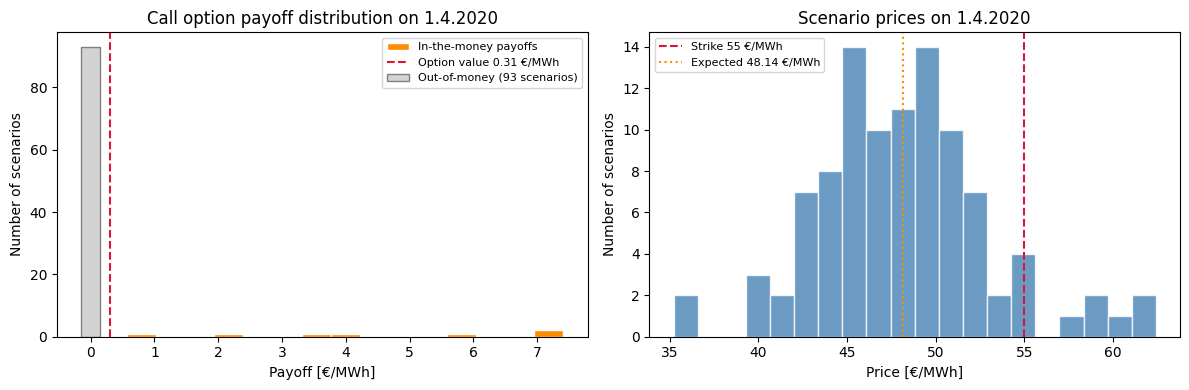

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: payoff distribution
ax = axes[0]
ax.hist(payoffs[payoffs > 0], bins=15, color="darkorange", edgecolor="white",
        label="In-the-money payoffs")
ax.bar(0, (payoffs == 0).sum(), width=0.3, color="lightgrey", edgecolor="grey",
       label=f"Out-of-money ({(payoffs == 0).sum()} scenarios)")
ax.axvline(option_value, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Option value {option_value:.2f} €/MWh")
ax.set_xlabel("Payoff [€/MWh]")
ax.set_ylabel("Number of scenarios")
ax.set_title("Call option payoff distribution on 1.4.2020")
ax.legend(fontsize=8)

# Right: price distribution on 1.4.2020 with strike line
ax2 = axes[1]
ax2.hist(prices_apr1, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(strike, color="crimson", linewidth=1.5, linestyle="--",
            label=f"Strike {strike:.0f} €/MWh")
ax2.axvline(expected_value, color="darkorange", linewidth=1.5, linestyle=":",
            label=f"Expected {expected_value:.2f} €/MWh")
ax2.set_xlabel("Price [€/MWh]")
ax2.set_ylabel("Number of scenarios")
ax2.set_title("Scenario prices on 1.4.2020")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/task_3d_option.png", dpi=150)
plt.show()
